# Ridge Regression - full feature set

**Downsampled data**

Author: Pete King

Here we test a Ridge regressor using the full feature set with downsampled (weekly) data.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.linear_model import Lasso, Ridge, ElasticNet

from helpers import data_prep as dp

IMAGE_DIR = Path.cwd() / 'images'
DATA_DIR = Path.cwd().parent / 'data' / 'downsample' / 'W' / 'train-val-test'
TRAIN_DATA_FILE = DATA_DIR / 'train_BASE_DATA.csv'
VAL_DATA_FILE = DATA_DIR / 'val_BASE_DATA.csv'
TICKER = 'SPY'  # ETF selected for this analysis

## I. Import data

We have already split our data into training and validation sets.  We reserve the held-out validation set (val_df) to plot predictions for comparisons against other models, but we further divide the training set into cross-validation folds to take advantage of scikit-learn's [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) function.  This gives us an easy way to apply scikit-learn's standard cross-validation (CV) methods for hyperparameter optimization while preserving chronological order between training and validation subsets within CV folds.

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)

In [3]:
# Separate features from labels; include all features, including daily return
data_cols, _ = dp.get_X_y_cols(train_df, returns=True)
label_col = [TICKER + '_vol_target']
# Training set
X_train = train_df.dropna()[data_cols].astype(np.float32)
y_train = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Validation set
X_val = val_df.dropna()[data_cols].astype(np.float32)
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=52,
    gap=1
)

### Scale data

In [4]:
# Scale input features
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=data_cols
)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=data_cols)

## II. Define model, fit to data, and evaluate performance

Here we tune the hyperparameter 'alpha', which controls the degree of regularization in the model by scaling the L2-norm loss term in the linear regression.  A higher 'alpha' value provides greater regularization, which prevents overfitting but can lead to biased estimates.

In [5]:
# Define model, metrics, and Grid Search for hyperparameter tuning
estimator = Ridge()
metrics = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MSE': 'neg_mean_squared_error',
    'r2': 'r2'
}
params = {
    'alpha': [0.01, 0.1, 1, 10]
}
reg = GridSearchCV(
    estimator,
    params,
    scoring=metrics,
    refit='MAE',
    cv=ts_cv
)

In [6]:
reg.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'RMSE': 'neg_root_mean_squared_error', 'r2': 'r2'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'MAE'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl... test_size=52)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

### Visualize performance; Check evaluation metrics

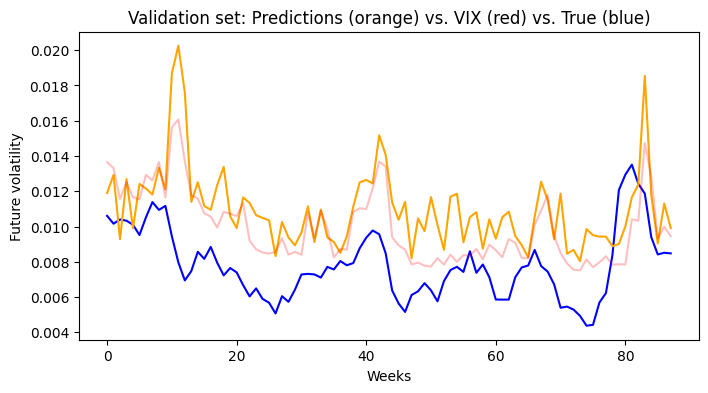

In [7]:
# Use the best estimator to make predictions on the validation set
best = reg.best_estimator_
preds = best.predict(X_val_scaled)
# The VIX estimates annualized volatility for the next 30 days
vix = val_df['^VIX'].values / np.sqrt(252) / 100

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
x = range(len(y_val))
ax.set_title('Validation set: Predictions (orange) vs. VIX (red) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Weeks')
ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')
ax.plot(x, vix, color='red', alpha=0.25)
fig.savefig(IMAGE_DIR / 'W-Ridge-full')

In [8]:
metrics = {
    'MAE': mean_absolute_error,
    'R2': r2_score,
}
# Out-of-sample R-squared compares model performance to baseline (VIX)
r2_oos = 1 - (
    mean_absolute_error(y_val, preds)
    / mean_absolute_error(y_val, vix)
)
# Display results
for metric, scorer in metrics.items():
    print(f'Model {metric}: {scorer(y_val, preds):.5f}')
    print(f'VIX {metric}:   {scorer(y_val, vix):.5f}')
    print('---')
print(f'Model R2-OOS: {r2_oos:.2f}')

Model MAE: 0.00339
VIX MAE:   0.00249
---
Model R2: -3.06625
VIX R2:   -1.11244
---
Model R2-OOS: -0.36


A negative out-of-sample R-squared score indicates that our model performs worse than the baseline.

## III. Inspect model

Since we scaled all input features in the range (0, 1), we can look at the coefficients assigned to each feature to understand which ones are assigned the most weight (greatest coefficients) in the regression.

In [9]:
feature_importances = list(zip(best.feature_names_in_, best.coef_))
for feature, coef in sorted(feature_importances, key=lambda i: -np.abs(i[1])):
    print(f'{feature}: {coef:2.3f}')

^VXN: 0.004
^MOVE: 0.004
^VIX: 0.003
three_month_yield_diff: -0.002
six_month_yield_diff: -0.002
XLK_vol-h: 0.002
QQQ_vol-h: 0.002
XLY_vol-h: 0.002
BIL_vol-h: -0.002
producer_price_index_chg: -0.002
real_GDP_chg: -0.002
BIL_ret-h: 0.002
core_PCE_chg: 0.002
XLV_vol-h: 0.002
consumer_price_index_chg: -0.002
debt_interest_chg: -0.002
SPY_vol-h: 0.002
SHY_vol-h: 0.002
one_year_yield_diff: -0.002
XLP_vol-h: 0.001
^GSPC_vol-h: 0.001
XLK_ret-h: -0.001
NG=F_vol-h: 0.001
XLRE_vol-h: 0.001
QQQ_ret-h: -0.001
^FTSE_ret-h: -0.001
GC=F_vol-h: 0.001
XLF_ret-h: -0.001
nominal_GDP_chg: -0.001
^FTSE_vol-h: 0.001
NG=F_ret-h: 0.001
^HSI_ret-h: 0.001
core_PCI_chg: 0.001
XLU_vol-h: 0.001
^HSI_vol-h: 0.001
HG=F_vol-h: -0.001
GLD_vol-h: 0.001
average_duration_of_unemployment_chg: -0.001
IWM_ret-h: -0.001
^GSPC_ret-h: -0.001
XLE_vol-h: 0.001
XLB_ret-h: -0.001
personal_consumption_expenditure_chg: -0.001
SPY_ret-h: -0.001
XLI_vol-h: 0.001
XLB_vol-h: 0.001
TLT_vol-h: 0.001
GC=F_ret-h: -0.001
TIP_ret-h: -0.001
SH

Once again we note how important the volatility indexes (VIX, VXN, MOVE) are to our model's own predictions.